In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [5]:
trades = pd.read_csv('historical_data.csv')
sentiment = pd.read_csv('fear_greed_index.csv')

print(trades.head())
print(sentiment.head())

                                      Account  Coin  Execution Price  \
0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9769   
1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9800   
2  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9855   
3  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9874   
4  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9894   

   Size Tokens  Size USD Side     Timestamp IST  Start Position Direction  \
0       986.87   7872.16  BUY  02-12-2024 22:50        0.000000       Buy   
1        16.00    127.68  BUY  02-12-2024 22:50      986.524596       Buy   
2       144.09   1150.63  BUY  02-12-2024 22:50     1002.518996       Buy   
3       142.98   1142.04  BUY  02-12-2024 22:50     1146.558564       Buy   
4         8.73     69.75  BUY  02-12-2024 22:50     1289.488521       Buy   

   Closed PnL                                   Transaction Hash     Order ID  \
0         0.0  0xec0945

In [6]:
trades.columns = trades.columns.str.strip().str.lower()
sentiment.columns = sentiment.columns.str.strip().str.lower()

print("Trades columns:\n", trades.columns)
print("\nSentiment columns:\n", sentiment.columns)

Trades columns:
 Index(['account', 'coin', 'execution price', 'size tokens', 'size usd', 'side',
       'timestamp ist', 'start position', 'direction', 'closed pnl',
       'transaction hash', 'order id', 'crossed', 'fee', 'trade id',
       'timestamp'],
      dtype='object')

Sentiment columns:
 Index(['timestamp', 'value', 'classification', 'date'], dtype='object')


In [7]:
# Convert trades timestamp (IMPORTANT FIX)
trades['timestamp ist'] = pd.to_datetime(trades['timestamp ist'], dayfirst=True)

# Extract date
trades['date'] = trades['timestamp ist'].dt.date

# Fix sentiment date
sentiment['date'] = pd.to_datetime(sentiment['date']).dt.date

In [8]:
df = pd.merge(trades, sentiment[['date', 'classification']], on='date', how='left')

df.head()

,account,coin,execution price,size tokens,size usd,side,timestamp ist,start position,direction,closed pnl,transaction hash,order id,crossed,fee,trade id,timestamp,date,classification
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,2024-12-02 22:50:00,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-12-02,Extreme Greed
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,2024-12-02 22:50:00,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-12-02,Extreme Greed
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,2024-12-02 22:50:00,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-12-02,Extreme Greed
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,2024-12-02 22:50:00,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-12-02,Extreme Greed
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,2024-12-02 22:50:00,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-12-02,Extreme Greed


In [9]:
# Profit flag
df['is_profit'] = df['closed pnl'] > 0

# Trade value
df['trade_value'] = df['execution price'] * df['size tokens']

In [10]:
pnl_analysis = df.groupby('classification')['closed pnl'].agg(['mean', 'sum'])
print("\nPnL Analysis:\n", pnl_analysis)


PnL Analysis:
                       mean           sum
classification                          
Extreme Fear     74.125083  5.711338e+05
Extreme Greed   102.968269  1.785779e+06
Fear             75.662241  2.511911e+06
Greed            57.671379  1.589596e+06
Neutral          53.877473  1.155295e+06


In [11]:
win_rate = df.groupby('classification')['is_profit'].mean()
print("\nWin Rate:\n", win_rate)


Win Rate:
 classification
Extreme Fear     0.365607
Extreme Greed    0.484230
Fear             0.449321
Greed            0.376338
Neutral          0.427599
Name: is_profit, dtype: float64


In [12]:
size_analysis = df.groupby('classification')['size usd'].mean()
print("\nAverage Trade Size (USD):\n", size_analysis)
total_size = df.groupby('classification')['size usd'].sum()
print("\nTotal Trade Volume (USD):\n", total_size)


Average Trade Size (USD):
 classification
Extreme Fear      5103.345014
Extreme Greed     5088.232888
Fear             10059.218024
Greed             8452.380085
Neutral           6254.840114
Name: size usd, dtype: float64

Total Trade Volume (USD):
 classification
Extreme Fear     3.932127e+07
Extreme Greed    8.824522e+07
Fear             3.339560e+08
Greed            2.329730e+08
Neutral          1.341225e+08
Name: size usd, dtype: float64


In [13]:
trade_count = df.groupby('classification').size()
print("\nTrade Count:\n", trade_count)


Trade Count:
 classification
Extreme Fear      7705
Extreme Greed    17343
Fear             33199
Greed            27563
Neutral          21443
dtype: int64


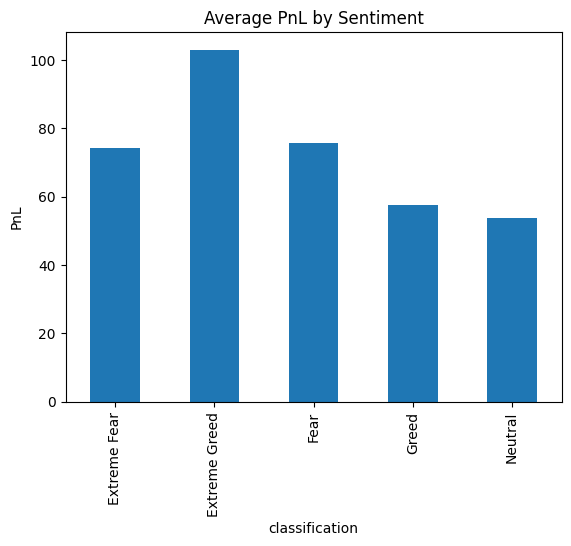

In [14]:
df.groupby('classification')['closed pnl'].mean().plot(kind='bar')
plt.title("Average PnL by Sentiment")
plt.ylabel("PnL")
plt.show()

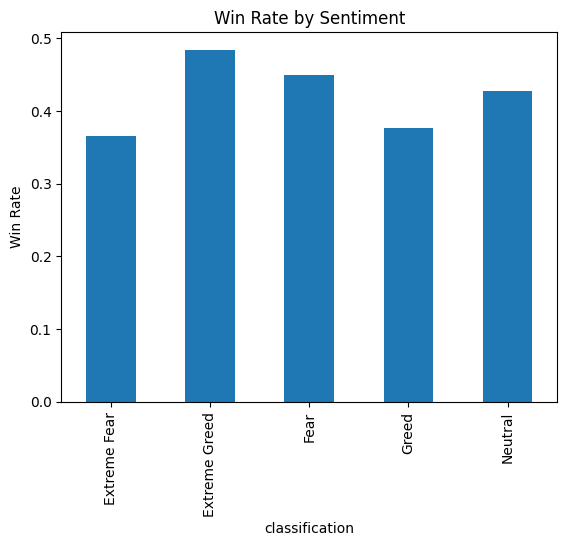

In [15]:
df.groupby('classification')['is_profit'].mean().plot(kind='bar')
plt.title("Win Rate by Sentiment")
plt.ylabel("Win Rate")
plt.show()

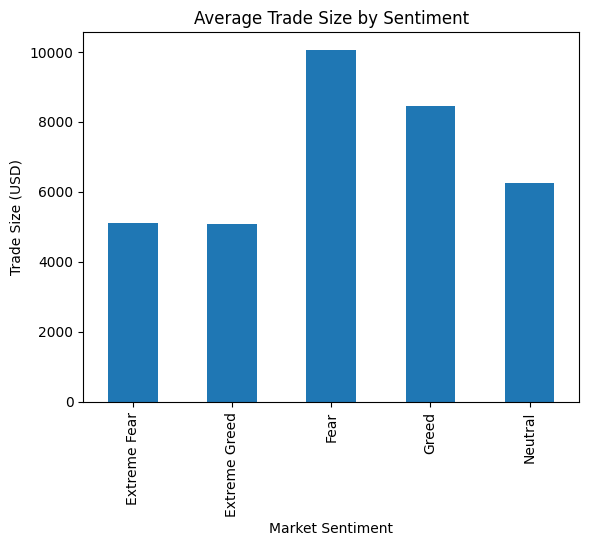

In [16]:
df.groupby('classification')['size usd'].mean().plot(kind='bar')
plt.title("Average Trade Size by Sentiment")
plt.ylabel("Trade Size (USD)")
plt.xlabel("Market Sentiment")
plt.show()

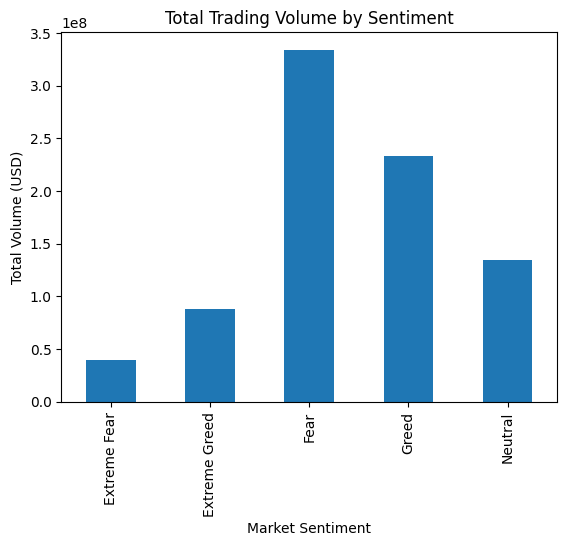

In [17]:
df.groupby('classification')['size usd'].sum().plot(kind='bar')
plt.title("Total Trading Volume by Sentiment")
plt.ylabel("Total Volume (USD)")
plt.xlabel("Market Sentiment")
plt.show()

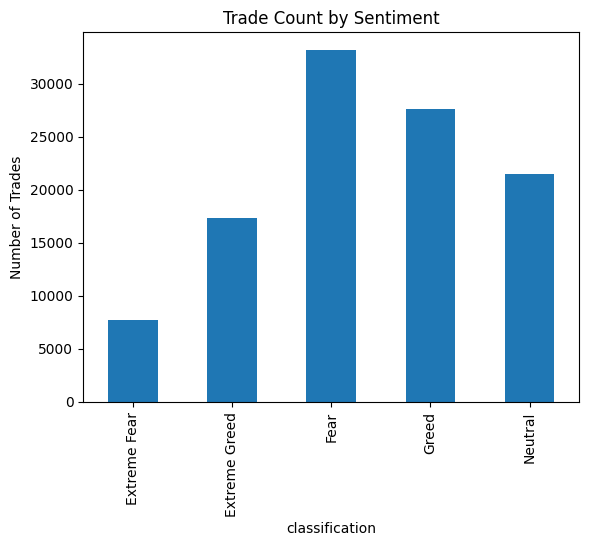

In [18]:
df.groupby('classification').size().plot(kind='bar')
plt.title("Trade Count by Sentiment")
plt.ylabel("Number of Trades")
plt.show()

In [19]:
top_traders = df.groupby('account')['closed pnl'].sum().sort_values(ascending=False).head(10)
print("\nTop Traders:\n", top_traders)


Top Traders:
 account
0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23    2.143383e+06
0x083384f897ee0f19899168e3b1bec365f52a9012    1.600230e+06
0xbaaaf6571ab7d571043ff1e313a9609a10637864    9.401638e+05
0x513b8629fe877bb581bf244e326a047b249c4ff1    8.404226e+05
0x430f09841d65beb3f27765503d0f850b8bce7713    4.165419e+05
0x72c6a4624e1dffa724e6d00d64ceae698af892a0    4.030115e+05
0x75f7eeb85dc639d5e99c78f95393aa9a5f1170d4    3.790954e+05
0x4f93fead39b70a1824f981a54d4e55b278e9f760    3.089759e+05
0x420ab45e0bd8863569a5efbb9c05d91f40624641    1.995056e+05
0x6d6a4b953f202f8df5bed40692e7fd865318264a    1.087312e+05
Name: closed pnl, dtype: float64


In [20]:
trader_pnl = df.groupby('account')['closed pnl'].sum()

top = trader_pnl.nlargest(10).index
bottom = trader_pnl.nsmallest(10).index

df['trader_type'] = df['account'].apply(lambda x: 'top' if x in top else ('bottom' if x in bottom else 'mid'))

comparison = df.groupby(['trader_type', 'classification'])['closed pnl'].mean()
print(comparison)

trader_type  classification
bottom       Extreme Fear      -75.847827
             Extreme Greed      23.111120
             Fear                5.828067
             Greed              13.131166
             Neutral             2.163759
top          Extreme Fear       92.696700
             Extreme Greed     167.242928
             Fear               91.233826
             Greed              89.109746
             Neutral            83.069726
Name: closed pnl, dtype: float64


In [21]:
print("Trades Shape:", trades.shape)
print("Sentiment Shape:", sentiment.shape)

print("\nMissing Values:\n", trades.isnull().sum())
print("\nDuplicates:", trades.duplicated().sum())

Trades Shape: (107259, 17)
Sentiment Shape: (2644, 4)

Missing Values:
 account             0
coin                0
execution price     0
size tokens         0
size usd            0
side                0
timestamp ist       0
start position      0
direction           0
closed pnl          0
transaction hash    0
order id            0
crossed             0
fee                 0
trade id            0
timestamp           0
date                0
dtype: int64

Duplicates: 0


In [22]:
daily_metrics = df.groupby(['date', 'classification']).agg({
    'closed pnl': 'sum',
    'is_profit': 'mean',
    'size usd': 'sum',
    'account': 'count'
}).rename(columns={'account': 'trade_count'})

daily_metrics.head()

,,closed pnl,is_profit,size usd,trade_count
date,classification,,,,
2023-05-01,Greed,0.000000,0.000000,477.00,3
2023-12-05,Extreme Greed,0.000000,0.000000,50005.83,9
2023-12-14,Greed,-205.434737,0.363636,113203.35,11
2023-12-15,Greed,-24.632034,0.000000,10609.95,2
2023-12-16,Greed,0.000000,0.000000,15348.77,3


In [23]:
long_short = df.groupby(['classification', 'side']).size().unstack()
print(long_short)

side              BUY   SELL
classification              
Extreme Fear     4453   3252
Extreme Greed    7949   9394
Fear            16777  16422
Greed           13429  14134
Neutral         11761   9682


In [24]:
trade_counts = df.groupby('account').size()

frequent = trade_counts[trade_counts > trade_counts.median()].index

df['trader_freq'] = df['account'].apply(lambda x: 'frequent' if x in frequent else 'infrequent')

df.groupby(['trader_freq', 'classification'])['closed pnl'].mean()

trader_freq  classification
frequent     Extreme Fear       44.401756
             Extreme Greed     101.809866
             Fear               38.230889
             Greed              37.432340
             Neutral            45.856677
infrequent   Extreme Fear      270.480960
             Extreme Greed     112.372530
             Fear              365.942769
             Greed             242.750205
             Neutral           122.775254
Name: closed pnl, dtype: float64